In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [106]:
# Initialize pieces
pieces_list = [
    [np.r_[0,1], np.r_[0,2], np.r_[1,0], np.r_[2,0]],
    [np.r_[0,1], np.r_[1,1], np.r_[1,0]],
    [np.r_[0,1], np.r_[1,0]],
    [np.r_[0,1], np.r_[0,2], np.r_[1,0], np.r_[1,2]],
    [np.r_[0,1], np.r_[1,0], np.r_[-1,0], np.r_[0,-1]],
    [np.r_[0,1], np.r_[0,2], np.r_[0,3], np.r_[1,0]],
    [np.r_[0,1], np.r_[0,2], np.r_[0,3]],
    [np.r_[0,1], np.r_[0,2], np.r_[0,3], np.r_[1,1]],
    [np.r_[0,1], np.r_[1,1], np.r_[1,2], np.r_[1,3]],
    [np.r_[0,1], np.r_[1,1], np.r_[1,2], np.r_[2,2]],
    [np.r_[0,1], np.r_[1,1], np.r_[1,0], np.r_[0,2]],
    [np.r_[0,1], np.r_[0,2], np.r_[1,0]]
            ]
board_size = 10

colors = ["midnightblue", "yellow", "darkorchid", "lime", "saddlebrown", "pink", "deepskyblue", "olivedrab", "seagreen", "red", "indigo", "orangered", "black", "grey"]

In [124]:
# -2: full, -1: free, [0 ... 11]: pieces

free_val = -1

class board:
    def __init__(self):
        self.board = np.ones((board_size, board_size)).astype(np.int8)
        self.board = self.board * -1
        self.current_pieces = []
        for i in range(10):
            self.board[i,i+1:]=-2
            
    def does_fit(self, pos, piece):
        if piece.id in self.current_pieces or self.board[tuple(pos)] != free_val or not(0 <=pos[0]<board_size and 0 <=pos[1]<board_size):
            return False
        
        for p in piece.positions:
            if not (0 <= pos[0] + p[0] < board_size and 0 <= pos[1] + p[1] < board_size) or self.board[pos[0] + p[0], pos[1] + p[1]] != free_val:
                return False
        return True
    
    def set_piece(self, pos, piece):
        if self.does_fit(pos, piece):
            self.current_pieces.append(piece.id)
            self.board[pos[0], pos[1]] = piece.id
            for p in piece.positions:
                self.board[pos[0] + p[0], pos[1] + p[1]] = piece.id
    
    def visualize(self):
        plt.figure(figsize=(7, 7))
        
        plt.xlim(-1, 10)
        plt.ylim(-1, 10)
        
        for i in range(10):
            for j in range(10):
                plt.plot(j, 9 - i, marker="o", markersize=20, markeredgecolor=colors[self.board[i][j]], markerfacecolor=colors[self.board[i][j]])
        
        plt.show()

In [56]:
class piece:
    def __init__(self, id, pivot = np.r_[0,0]):
        self.id = id
        self.positions = pieces_list[self.id]
        self.pivot = pivot
    
    def show(self):
        show_pivot = (3,3)
        
        temp_mat = np.zeros((7,7))
        temp_mat[show_pivot] = 1
        for i in self.positions:
            temp_mat[i[0] + show_pivot[0], i[1] + show_pivot[1]] = 1
        print(temp_mat)
        
    def visualize(self):
        plt.figure(figsize=(4, 4))
        plt.xlim(-4, 4)
        plt.ylim(-4, 4)
        show_pivot = (0,0)
        
        points = [show_pivot]
        
        plt.plot(points[-1][0], points[-1][1], marker="o", markersize=20, markeredgecolor=colors[self.id], markerfacecolor=colors[self.id])
        for i in self.positions:
            points.append((i[0] + show_pivot[0], i[1] + show_pivot[1]))
            plt.plot(points[-1][0], points[-1][1], marker="o", markersize=20, markeredgecolor=colors[self.id], markerfacecolor=colors[self.id])
        plt.show()
    
    def rotate_theta(self, theta):
        new_positions = []
        for pos in self.positions:
            new_positions.append(pos@[[np.cos(theta),np.sin(theta)],[-1*np.sin(theta),np.cos(theta)]])
        self.positions = np.array(new_positions).astype(np.int8)
        return self.positions
    
    def rotate_R(self):
        return self.rotate_theta(-np.pi/2)
        
    
    def rotate_L(self):
        return self.rotate_theta(np.pi/2)
    
    def vertical_flip(self):
        new_positopns = []
        for pos in self.positions:
            new_pos = pos.copy()
            new_pos[0] = new_pos[0]*-1
            new_positopns.append(new_pos)
        self.positions = new_positopns
        return new_positopns
    
    def horizental_flip(self):
        new_positopns = []
        for pos in self.positions:
            new_pos = pos.copy()
            new_pos[1] = new_pos[1]*-1
            new_positopns.append(new_pos)
        self.positions = new_positopns
        return new_positopns

In [109]:
p = piece(2)

In [110]:
print(p.positions)
print(p.id)

[array([0, 1], dtype=int32), array([1, 0], dtype=int32)]
2


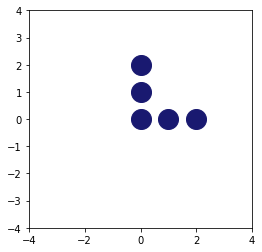

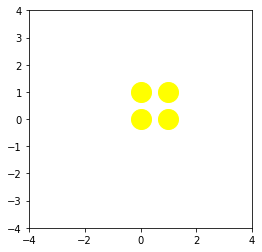

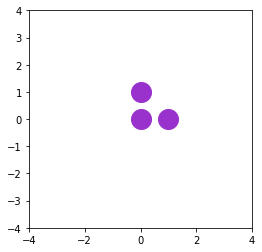

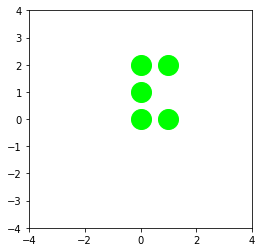

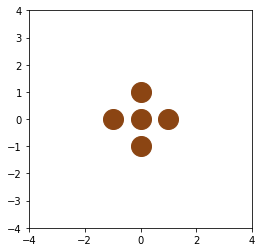

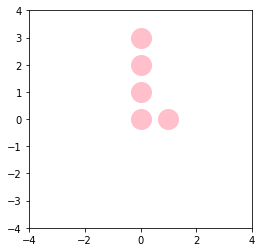

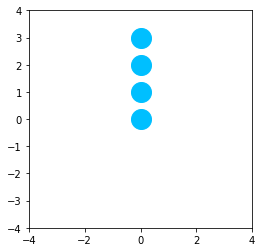

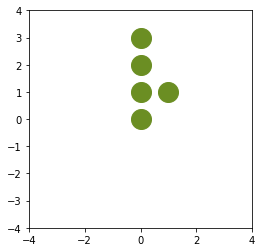

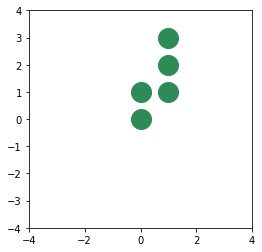

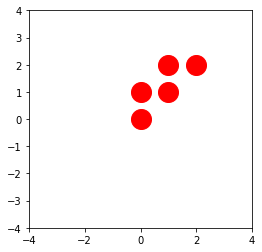

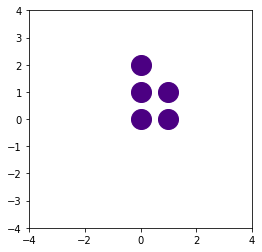

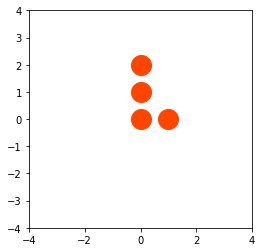

In [59]:
# Visualize all pieces
for i in range(12):
    tp = piece(i)
    tp.visualize()

In [113]:
b = board()

In [114]:
print(b.current_pieces)
print(b.board)

[]
[[-1 -2 -2 -2 -2 -2 -2 -2 -2 -2]
 [-1 -1 -2 -2 -2 -2 -2 -2 -2 -2]
 [-1 -1 -1 -2 -2 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -2 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -1 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -1 -1 -2 -2]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -2]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]]


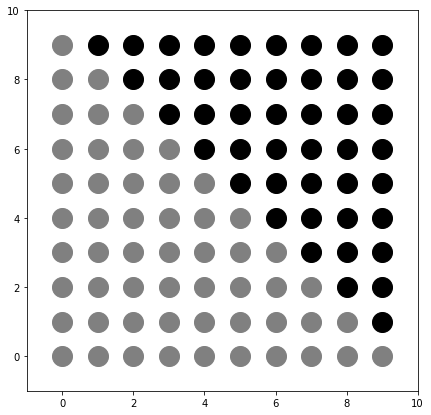

In [115]:
b.visualize()

In [116]:
b.does_fit((1,0), p)

True

In [10]:
p.rotate_R()
print(p.positions)

[[ 1  0]
 [ 0 -1]]


In [11]:
b.does_fit((1,0), p)

False

In [117]:
b.set_piece((2,1), p)

[2]
[[-1 -2 -2 -2 -2 -2 -2 -2 -2 -2]
 [-1 -1 -2 -2 -2 -2 -2 -2 -2 -2]
 [-1  2  2 -2 -2 -2 -2 -2 -2 -2]
 [-1  2 -1 -1 -2 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -1 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -1 -1 -2 -2]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -2]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]]


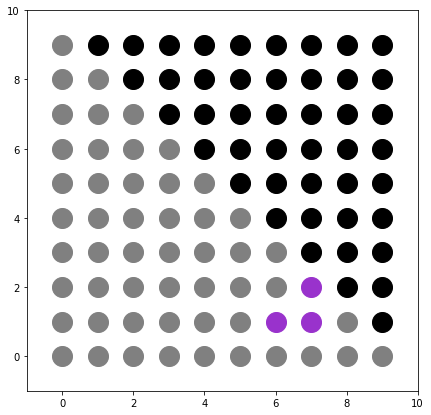

In [119]:
print(b.current_pieces)
print(b.board)
b.visualize()

In [125]:
# Def board for test:
b_test = board()

In [126]:
p_test = []
pos_test = []

# 1
p_test.append(piece(5))
p_test[-1].vertical_flip()
pos_test.append((9,0))

# 2
p_test.append(piece(1))
pos_test.append((8,4))

# 3
p_test.append(piece(7))
p_test[-1].horizental_flip()
p_test[-1].vertical_flip()
pos_test.append((9,9))

# 4
p_test.append(piece(3))
p_test[-1].rotate_L()
pos_test.append((8,1))

# 5
p_test.append(piece(4))
pos_test.append((7,3))

#6
p_test.append(piece(2))
p_test[-1].rotate_R()
p_test[-1].rotate_R()
pos_test.append((8,7))


print(p_test[-1].positions)
p_test[-1].show()

[[ 0 -1]
 [-1  0]]
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]


In [127]:
for i in p_test:
    i.show()

[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 

In [128]:
for i in np.arange(0, len(p_test)):
    print(b_test.does_fit(pos_test[i], p_test[i]))
    b_test.set_piece(pos_test[i], p_test[i])
    print(b_test.board)

True
[[-1 -2 -2 -2 -2 -2 -2 -2 -2 -2]
 [-1 -1 -2 -2 -2 -2 -2 -2 -2 -2]
 [-1 -1 -1 -2 -2 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -2 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -1 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -1 -1 -2 -2]
 [ 5 -1 -1 -1 -1 -1 -1 -1 -1 -2]
 [ 5  5  5  5 -1 -1 -1 -1 -1 -1]]
True
[[-1 -2 -2 -2 -2 -2 -2 -2 -2 -2]
 [-1 -1 -2 -2 -2 -2 -2 -2 -2 -2]
 [-1 -1 -1 -2 -2 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -2 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -1 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -1 -1 -2 -2]
 [ 5 -1 -1 -1  1  1 -1 -1 -1 -2]
 [ 5  5  5  5  1  1 -1 -1 -1 -1]]
True
[[-1 -2 -2 -2 -2 -2 -2 -2 -2 -2]
 [-1 -1 -2 -2 -2 -2 -2 -2 -2 -2]
 [-1 -1 -1 -2 -2 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -2 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -1 -2 -2 -2]
 [-1 -1 -1 -1 -1 -1 -1 -1 -2 -2]
 [ 5 -1 -1 -1  1  1 -1 -1  7 -2]
 [ 5  5  5  5  1  1  7  7 

[5, 1, 7, 3, 4, 2]


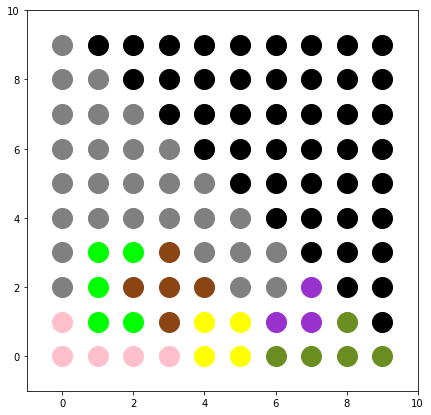

In [129]:
print(b_test.current_pieces)
b_test.visualize()

In [277]:
# Dont touch ME
tt = piece([np.r_[0,1], np.r_[1,0], np.r_[1,2], np.r_[2,1]], np.r_[1,1])
tt.show()

TypeError: list indices must be integers or slices, not list

In [51]:
# functions call
p.vertical_flip()
p.horizental_flip()
p.rotate_theta(-np.pi/2)
p.rotate_R()

for i in pieces_list:
    temp_p = piece(i)
    temp_p.show()
    print("____________")

[array([0, 1], dtype=int32), array([-1,  0], dtype=int32)]